
Differentially expressed genes between Healthy (HIHAtlas) and GBM (GBMap) cells, on the pre-built macrophage/monocyte subset of the harmony-integrated dataset (10_subset_macro.h5ad).
 
Method: sc.tl.rank_genes_groups, Wilcoxon rank-sum test, use_raw=False - same convention used for DEG comparisons elsewhere (per-group Wilcoxon, use_raw=False, no extra normalization since ranking is rank-based).
 
Cell types already contained in 10_subset_macro.h5ad: \
    - Macrophages SPP1 \
    - Macro. and Mono. Prolif \
    - TAMs C1QC \
    - TAMs proinflammatory \
    - Monocytes 


In [22]:
import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc
import os
import re

In [6]:
BASE = "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune"
OUT_DIR = f"{BASE}/results/10_integration_GBM_HIHA"
os.makedirs(OUT_DIR, exist_ok=True)

adata = ad.read_h5ad(f"{BASE}/data/10_integration_GBM_HIHA/10_subset_macro.h5ad")
print("Loaded subset shape:", adata.shape)
print(adata.obs.columns.tolist())


Loaded subset shape: (43358, 22586)
['donor_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'sex_ontology_term_id', 'suspension_type', 'tissue_ontology_term_id', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'decoupler_level1_celltype', 'decoupler_level1_score', 'decoupler_level2_celltype', 'decoupler_level2_score', 'dataset', 'dataset_batch']


## Compute DEG between datasets (healthy vs. GBM)

In [7]:
if "condition" in adata.obs.columns:
    print(adata.obs["condition"].value_counts())
elif "dataset" in adata.obs.columns:
    label_map = {"HIHAtlas": "Healthy", "GBMap": "GBM"}
    adata.obs["condition"] = adata.obs["dataset"].map(label_map)
    print(adata.obs["condition"].value_counts())
else:
    raise ValueError(
        "Neither 'condition' nor 'dataset' found in adata.obs. Inspect "
        "the printed obs columns above and set the grouping column "
        "manually before proceeding."
    )

condition
GBM        25000
Healthy    18358
Name: count, dtype: int64


In [9]:
print(f"X.min()={adata.X.min():.3f}  X.max()={adata.X.max():.3f}  "
      f"log1p flag={adata.uns.get('log1p')}")

X.min()=0.000  X.max()=9.039  log1p flag=None


In [15]:
sc.tl.rank_genes_groups(
    adata,
    groupby="condition",
    method="wilcoxon",   
    use_raw=False,
)
 
deg_df = sc.get.rank_genes_groups_df(adata, group=None)
out_csv = os.path.join(OUT_DIR, "10_06_deg_macrophages_healthy_vs_gbm.csv")
deg_df.to_csv(out_csv, index=False)
print(f"Saved DEG results to {out_csv}")
 
print("\nTop 20 genes per group:")
print(
    deg_df.sort_values(["group", "scores"])
    .groupby("group", observed=True)
    .head(20)
    .to_string(index=False)
)

Saved DEG results to /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/10_integration_GBM_HIHA/10_06_deg_macrophages_healthy_vs_gbm.csv

Top 20 genes per group:
  group   names      scores  logfoldchanges  pvals  pvals_adj
    GBM   RPL30 -140.340057       -2.457724    0.0        0.0
    GBM   RPS24 -136.005768       -2.352885    0.0        0.0
    GBM  S100A4 -134.893372       -3.545738    0.0        0.0
    GBM   RPL11 -133.021103       -2.348501    0.0        0.0
    GBM   RPS26 -131.492874       -2.797323    0.0        0.0
    GBM    NACA -131.073074       -2.280087    0.0        0.0
    GBM    CD52 -129.100571       -3.776495    0.0        0.0
    GBM    FCN1 -128.903534       -4.124057    0.0        0.0
    GBM    RPS7 -128.753998       -2.385526    0.0        0.0
    GBM    RPS8 -128.339096       -2.354409    0.0        0.0
    GBM    RPL6 -128.297318       -2.311602    0.0        0.0
    GBM    CD48 -127.439194       -3.319536    0.0        0.0
    GBM   RPL28 -1

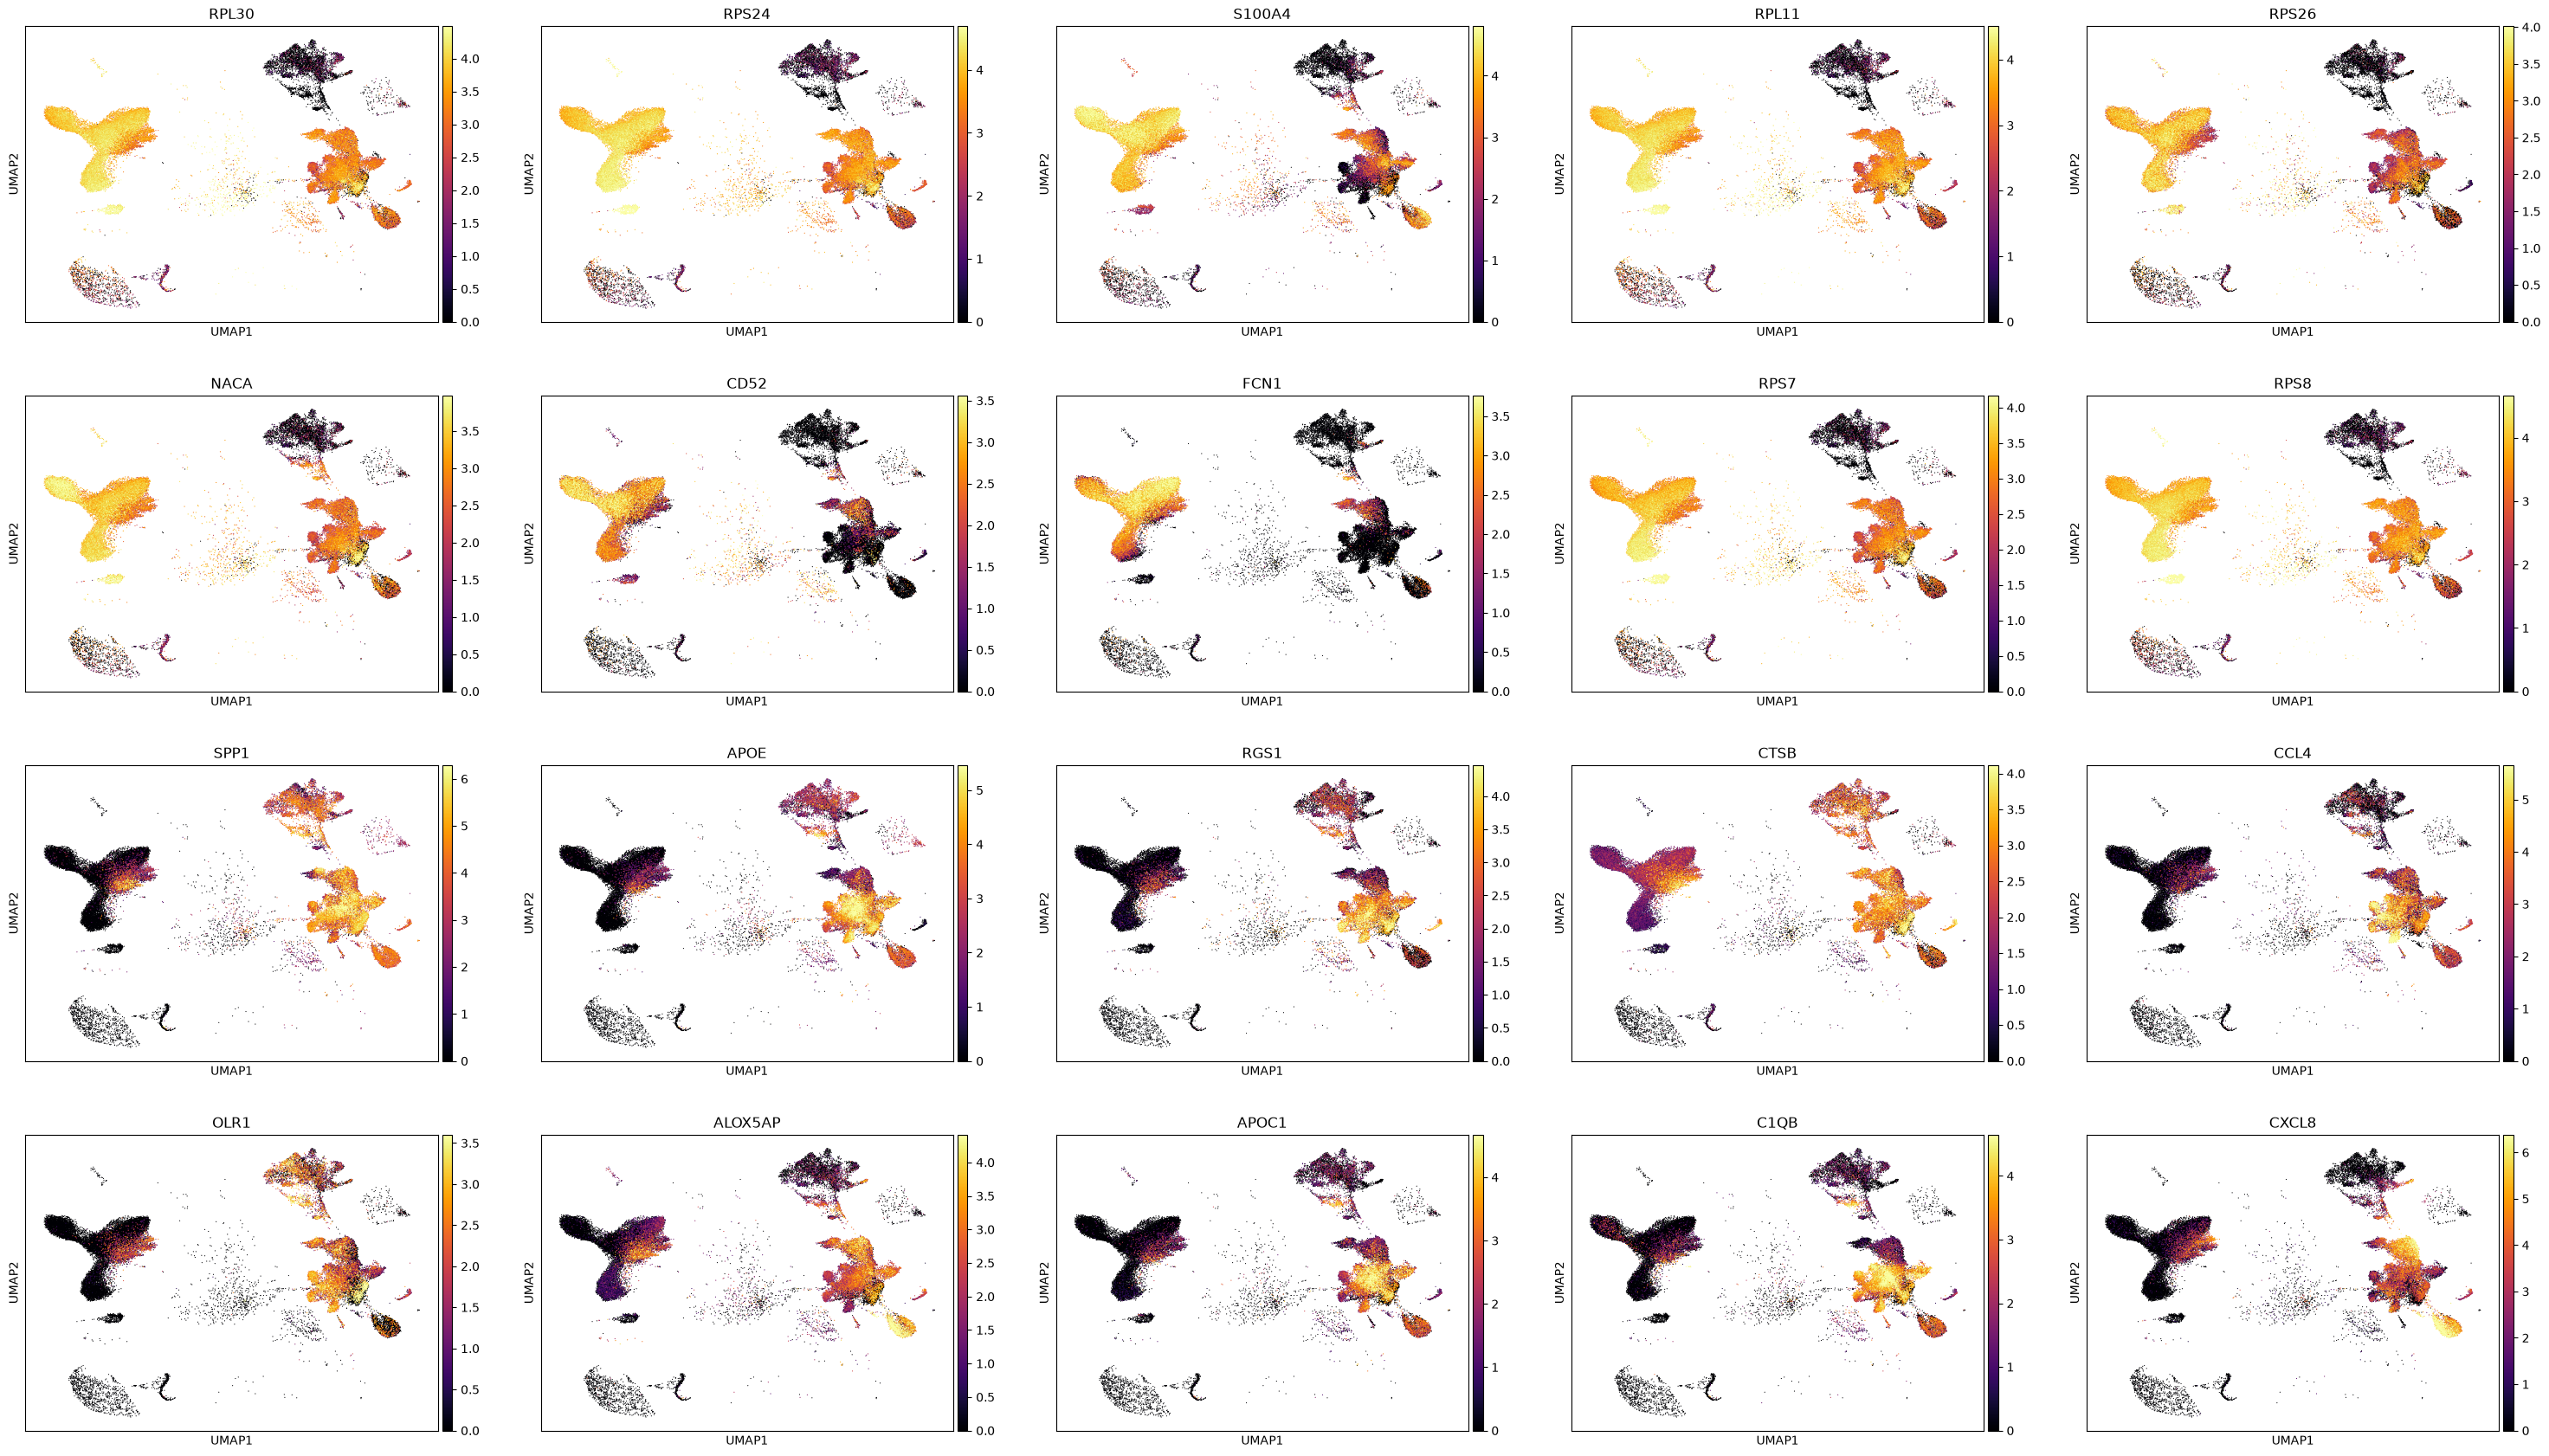

In [16]:
top10_healthy = deg_df[deg_df["group"] == "Healthy"].head(10)["names"].tolist()
top10_gbm = deg_df[deg_df["group"] == "GBM"].head(10)["names"].tolist()
top_genes_combined = top10_healthy + top10_gbm

sc.pl.umap(adata, color=top_genes_combined, ncols=5, vmax="p99", color_map = "inferno")

### Volcano plot

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np

# df = deg_df[deg_df["group"] == "GBM"].copy()  # pick one group
# df["neg_log10_padj"] = -np.log10(df["pvals_adj"].clip(lower=1e-300))

# fig, ax = plt.subplots(figsize=(6, 5))
# colors = np.where(
#     (df["pvals_adj"] < 0.05) & (df["logfoldchanges"].abs() > 1), "#C0392B", "grey"
# )
# ax.scatter(df["logfoldchanges"], df["neg_log10_padj"], c=colors, s=8, alpha=0.6)
# ax.axhline(-np.log10(0.05), linestyle="--", color="black", linewidth=0.8)
# ax.axvline(1, linestyle="--", color="black", linewidth=0.8)
# ax.axvline(-1, linestyle="--", color="black", linewidth=0.8)
# ax.set_xlabel("log2 fold change")
# ax.set_ylabel("-log10(padj)")

## Build combined obs column (healthy_X vs disease_X) and compute DEG on each celltype

In [20]:
adata.obs["decoupler_level1_celltype"].value_counts()

decoupler_level1_celltype
Monocytes                   15528
Macro. and mono. prolif.     9067
TAMs proinflammatory         6911
TAMs C1QC                    6852
Macrophages SPP1             5000
Name: count, dtype: int64

In [21]:
celltype_col = "decoupler_level1_celltype"
condition_col = "condition"

TARGET_CELLTYPES = [
    "Macrophages SPP1",
    "Macro. and mono. prolif.",
    "TAMs C1QC",
    "TAMs proinflammatory",
    "Monocytes",
]

In [23]:
def slugify(ct):
    # "TAMs C1QC" -> "TAMs_C1QC", "Macro. and Mono. Prolif" -> "Macro_and_Mono_Prolif"
    s = re.sub(r"[^\w\s]", "", ct)
    s = re.sub(r"\s+", "_", s.strip())
    return s
 
adata.obs["celltype_slug"] = adata.obs[celltype_col].astype(str).apply(slugify)
adata.obs["condition_celltype"] = (
    adata.obs[condition_col].astype(str) + "_" + adata.obs["celltype_slug"]
)
adata.obs["condition_celltype"] = adata.obs["condition_celltype"].astype("category")
 
print("\ncondition_celltype value counts:")
print(adata.obs["condition_celltype"].value_counts())


condition_celltype value counts:
condition_celltype
Healthy_Monocytes                10528
GBM_Macro_and_mono_prolif         5000
GBM_Macrophages_SPP1              5000
GBM_TAMs_C1QC                     5000
GBM_Monocytes                     5000
GBM_TAMs_proinflammatory          5000
Healthy_Macro_and_mono_prolif     4067
Healthy_TAMs_proinflammatory      1911
Healthy_TAMs_C1QC                 1852
Name: count, dtype: int64


In [27]:
MIN_CELLS = 10
all_results = []
 
for ct in TARGET_CELLTYPES:
    slug = slugify(ct)
    healthy_label = f"Healthy_{slug}"
    gbm_label = f"GBM_{slug}"
 
    n_healthy = (adata.obs["condition_celltype"] == healthy_label).sum()
    n_gbm = (adata.obs["condition_celltype"] == gbm_label).sum()
 
    if n_healthy < MIN_CELLS or n_gbm < MIN_CELLS:
        print(f"Skipping {ct}: n_healthy={n_healthy}, n_gbm={n_gbm} "
              f"(below MIN_CELLS={MIN_CELLS})")
        continue
 
    print(f"\n[{ct}] Healthy n={n_healthy}, GBM n={n_gbm} - running Wilcoxon")
 
    adata_ct = adata[adata.obs["celltype_slug"] == slug].copy()
    sc.tl.rank_genes_groups(
        adata_ct,
        groupby="condition_celltype",
        groups=[gbm_label],
        reference=healthy_label,
        method="wilcoxon",   
        use_raw=False,
    )
    deg_ct = sc.get.rank_genes_groups_df(adata_ct, group=gbm_label)
    deg_ct.insert(0, "celltype", ct)
    all_results.append(deg_ct)
 
deg_df = pd.concat(all_results, ignore_index=True)
out_csv = os.path.join(OUT_DIR, "10_06_deg_macro_percelltype.csv")
deg_df.to_csv(out_csv, index=False)
print(f"\nSaved per-cell-type DEG results to {out_csv}")
 
print("\nTop 10 genes per cell type (by pvals_adj):")
print(
    deg_df.sort_values(["celltype", "pvals_adj"])
    .groupby("celltype")
    .head(10)
    .to_string(index=False)
)
 

Skipping Macrophages SPP1: n_healthy=0, n_gbm=5000 (below MIN_CELLS=10)

[Macro. and mono. prolif.] Healthy n=4067, GBM n=5000 - running Wilcoxon

[TAMs C1QC] Healthy n=1852, GBM n=5000 - running Wilcoxon

[TAMs proinflammatory] Healthy n=1911, GBM n=5000 - running Wilcoxon

[Monocytes] Healthy n=10528, GBM n=5000 - running Wilcoxon

Saved per-cell-type DEG results to /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/10_integration_GBM_HIHA/10_06_deg_macro_percelltype.csv

Top 10 genes per cell type (by pvals_adj):
                celltype   names    scores  logfoldchanges  pvals  pvals_adj
Macro. and mono. prolif.    SPP1 77.276703       16.073946    0.0        0.0
Macro. and mono. prolif.    APOE 73.264618       14.680782    0.0        0.0
Macro. and mono. prolif.    C1QB 71.426888       10.158204    0.0        0.0
Macro. and mono. prolif.    C1QA 69.314819        7.707810    0.0        0.0
Macro. and mono. prolif.    RGS1 68.876549        7.388202    0.0        0.0
Ma